# [Demo] De Chains a Agents

Antes do agente atual havia as *chains*: composições fixas de prompt e modelo. A evolução vai do jeito
antigo ao padrão de hoje.

O que vamos ver:
- chains como contexto histórico, hoje em `langchain-classic`;
- LCEL, a composição com `|` que sucedeu as chains;
- o padrão atual, `create_agent`, mas ainda sem tools;
- como invocar o agente e ler a lista de mensagens da resposta.

## Setup

Carregamos as variáveis de ambiente (a chave `OPENAI_API_KEY` vem do `.env`) e inicializamos o modelo uma vez.

In [1]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(model="gpt-4o-mini", temperature=0)

## Chains: como era antes

Antes do agente atual, uma aplicação com LLM era montada como uma **chain**: uma sequência fixa de passos
(prompt, depois modelo). O LangChain ainda mantém essas peças legadas no pacote `langchain-classic`, para
quem migra um projeto antigo.

In [4]:
from langchain_core.prompts import PromptTemplate
from langchain_classic.chains import LLMChain

In [5]:
prompt_template = PromptTemplate.from_template(
    "Escreva uma orientação curta para o paciente antes de uma consulta de {especialidade}."
)

In [6]:
# Jeito manual: encadear prompt e modelo na mão, um invoke de cada vez
response = model.invoke(prompt_template.invoke({"especialidade": "cardiologia"}))
response

AIMessage(content='**Orientações para a Consulta de Cardiologia**\n\n1. **Histórico Médico**: Traga uma lista de seus medicamentos atuais, incluindo dosagens, e informe sobre qualquer condição médica pré-existente.\n\n2. **Sintomas**: Anote quaisquer sintomas que você esteja sentindo, como dor no peito, falta de ar, palpitações ou fadiga, e a frequência com que ocorrem.\n\n3. **Exames Anteriores**: Se possível, leve resultados de exames anteriores relacionados ao coração, como eletrocardiogramas, ecocardiogramas ou testes de esforço.\n\n4. **Estilo de Vida**: Esteja preparado para discutir seu estilo de vida, incluindo dieta, exercícios, consumo de álcool e tabaco.\n\n5. **Perguntas**: Prepare uma lista de perguntas ou preocupações que você gostaria de discutir com o cardiologista.\n\n6. **Chegada**: Chegue com antecedência para preencher formulários e relaxar antes da consulta.\n\nLembre-se de que a consulta é uma oportunidade para esclarecer suas dúvidas e entender melhor sua saúde c

In [7]:
chain = LLMChain(llm=model, prompt=prompt_template)

/var/folders/z8/8n6j5_4n14x36ycf1nrcr3pw0000gn/T/ipykernel_35371/3559033784.py:1: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 2.0.0. Use `RunnableSequence, e.g., `prompt | llm`` instead.
  chain = LLMChain(llm=model, prompt=prompt_template)


In [8]:
import langchain 
langchain.__version__

'1.3.13'

In [9]:
chain.invoke({"especialidade": "cardiologia"})

{'especialidade': 'cardiologia',
 'text': '**Orientações para a Consulta de Cardiologia**\n\n1. **Histórico Médico**: Traga uma lista de seus medicamentos atuais, incluindo dosagens, e informe sobre qualquer condição médica pré-existente, como diabetes, hipertensão ou problemas cardíacos na família.\n\n2. **Sintomas**: Anote quaisquer sintomas que você esteja sentindo, como dor no peito, falta de ar, palpitações ou fadiga, e a frequência com que ocorrem.\n\n3. **Exames Anteriores**: Se possível, leve resultados de exames anteriores relacionados ao coração, como eletrocardiogramas, ecocardiogramas ou testes de esforço.\n\n4. **Estilo de Vida**: Esteja preparado para discutir seu estilo de vida, incluindo dieta, exercícios, consumo de álcool e tabagismo.\n\n5. **Perguntas**: Prepare uma lista de perguntas que você gostaria de fazer ao cardiologista sobre sua saúde e tratamento.\n\n6. **Chegada**: Chegue com antecedência para preencher formulários e relaxar antes da consulta.\n\nLembre-se

## LCEL: prompt | llm | parser

A **LangChain Expression Language** substituiu a `LLMChain` por composição com o operador `|`: cada peça
recebe a saída da anterior. Um `parser` no fim extrai só o texto da resposta do modelo.

In [10]:
from langchain_core.output_parsers import StrOutputParser

In [11]:
parser = StrOutputParser()

In [12]:
chain = prompt_template | model | parser

In [13]:
print(chain.invoke({"especialidade": "dermatologia"}))

**Orientações para a Consulta de Dermatologia**

1. **Histórico Médico**: Traga uma lista de medicamentos que você está tomando e informe sobre condições médicas pré-existentes.

2. **Sintomas**: Anote quaisquer sintomas que você está enfrentando, como coceira, dor ou alterações na pele, e a duração deles.

3. **Histórico Familiar**: Informe se há histórico de doenças de pele na sua família, como psoríase ou câncer de pele.

4. **Cuidados Anteriores**: Se você já fez tratamentos ou usou produtos para a pele, traga informações sobre eles.

5. **Evite Maquiagem**: Se possível, venha sem maquiagem ou produtos na pele para que o dermatologista possa avaliar melhor sua condição.

6. **Perguntas**: Prepare uma lista de perguntas ou preocupações que você gostaria de discutir durante a consulta.

7. **Chegue Cedo**: Chegue com antecedência para preencher formulários e relaxar antes da consulta.

Lembre-se de que sua saúde é prioridade. Estamos aqui para ajudar!


In [14]:
chain.get_graph().print_ascii()

     +-------------+       
     | PromptInput |       
     +-------------+       
            *              
            *              
            *              
    +----------------+     
    | PromptTemplate |     
    +----------------+     
            *              
            *              
            *              
      +------------+       
      | ChatOpenAI |       
      +------------+       
            *              
            *              
            *              
   +-----------------+     
   | StrOutputParser |     
   +-----------------+     
            *              
            *              
            *              
+-----------------------+  
| StrOutputParserOutput |  
+-----------------------+  


## O padrão atual: create_agent

Uma chain, mesmo em LCEL, segue uma linha reta: sempre os mesmos passos, na mesma ordem. O `create_agent`
troca essa linha reta por um grafo do LangGraph, capaz de decidir o próximo passo a cada execução.

In [15]:
from IPython.display import Image, display
from langchain.agents import create_agent
from langchain.messages import HumanMessage

In [16]:
agent = create_agent(
    model=model,
    system_prompt="Você é o assistente da Clínica Alura. Responda de forma cordial, curta e objetiva.",
)

In [17]:
type(agent)

langgraph.graph.state.CompiledStateGraph

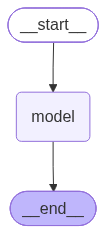

In [18]:
display(
    Image(agent.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0))
)

## Invocando o agente e lendo as mensagens

O agente não recebe um dict de variáveis como a chain: recebe uma lista de **mensagens**. A resposta
também vem como mensagens, uma conversa completa, não só o texto final.

In [19]:
response = agent.invoke(
    {
        "messages": [
            HumanMessage("Vocês atendem urgência odontológica?")
        ]
    }
)

In [20]:
response["messages"]

[HumanMessage(content='Vocês atendem urgência odontológica?', additional_kwargs={}, response_metadata={}, id='fe1b9ac3-1ea9-49bd-a1cb-73752a83e522'),
 AIMessage(content='Sim, atendemos urgências odontológicas. Recomendamos que entre em contato conosco para agendar uma consulta.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 41, 'total_tokens': 64, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_2b114d87de', 'id': 'chatcmpl-EAicy1AuPbhfZKSr73LZFAYjjZMcf', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fe338-24b7-77b1-904e-105602b8a303-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens'

In [21]:
print(response["messages"][-1].content)

Sim, atendemos urgências odontológicas. Recomendamos que entre em contato conosco para agendar uma consulta.


## Takeaway

De uma chain fixa (`prompt | llm | parser`) para um agente rodando sobre um grafo do LangGraph: essa é a
base do `create_agent`. Falta uma peça para o agente virar autônomo: uma tool, para agir no mundo real em
vez de só conversar.